# Modelamiento — Metropolitano Troncal (ATU · Week 08)

Modelo **específico** para `troncal` (no se mezcla con otros modos).

| | |
|--|--|
| Sistema | `troncal` |
| Grano | `estacion` |
| Fuente | `demanda_consolidada_fiable.parquet` |
| Forecast | Chronos Bolt + baselines (walk-forward) |
| Aforo | proxy presión demanda (no ocupación a bordo) |
| Decisión | regla U (abordar / esperar / cambiar) |

Helpers compartidos: `code/model/model_atu_common.py`.
Outputs: `code/model/outputs/troncal/`.


## 0. Setup


In [3]:

import os, sys, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TQDM_DISABLE"] = "1"
warnings.filterwarnings("ignore")

SISTEMA = "troncal"
COLOR = "#1f4e79"

def find_week08():
    p = Path.cwd().resolve()
    for cand in [p, *p.parents]:
        if (cand / "code" / "model" / "model_atu_common.py").exists():
            return cand
    raise FileNotFoundError("week08 no encontrado")

RAIZ = find_week08()
sys.path.insert(0, str(RAIZ / "code" / "model"))
import model_atu_common as M

OUT_DIR, FIGS = M.out_dirs(SISTEMA, RAIZ)
P = M.paths(RAIZ)
print("Sistema:", SISTEMA)
print("RAIZ   :", RAIZ)
print("OUT    :", OUT_DIR)
print("FIGS   :", FIGS)


Sistema: troncal
RAIZ   : /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08
OUT    : /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/code/model/outputs/troncal
FIGS   : /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week08/docs/images/model/troncal


### Qué encontramos (setup)

Notebook dedicado a **Metropolitano Troncal**. Mismos splits/días eval que el resto, pero pesos
entrenados **solo** con series de este sistema.


## 1. Carga y panel serie×hora


In [6]:

df_h = M.load_sistema(SISTEMA, RAIZ)
print("Filas:", f"{len(df_h):,}")
print("Series (unidades):", df_h["serie_id"].nunique())
print("Rango:", df_h["Fecha_Hora"].min(), "→", df_h["Fecha_Hora"].max())
print("Validaciones Σ:", f"{df_h['Validaciones'].sum():,.0f}")
print("Top 5 unidades por demanda media:")
top = (df_h.groupby("serie_id")["Validaciones"].mean().sort_values(ascending=False).head(5))
print(top.round(1).to_string())
df_h.head(3)


Filas: 394,200
Series (unidades): 45
Rango: 2025-01-01 00:00:00 → 2025-12-31 23:00:00
Validaciones Σ: 127,492,997
Top 5 unidades por demanda media:
serie_id
Naranjal            2440.7
Matellini           1122.0
Estacion Central     851.3
Angamos              720.8
Javier Prado         640.6


### Qué encontramos (carga)

Si el grano es `ruta`, las validaciones ya están **sumadas por paradero→ruta×hora**
(evita tratar cada paradero como serie independiente).


## 2. Grid + Chronos


In [9]:

import torch
from chronos import ChronosBoltPipeline

grid, series_ok = M.build_grid(df_h)
print("Grid:", grid.shape, "| series OK:", len(series_ok), "/", df_h["serie_id"].nunique())
print("Split:", M.SPLIT)
print("Días eval:", [str(d.date()) for d in M.DIAS_EVAL])

pipeline = ChronosBoltPipeline.from_pretrained(M.MODELO_CHRONOS)
print("Chronos cargado:", M.MODELO_CHRONOS)


Grid: (8760, 45) | series OK: 45 / 45
Split: 2025-10-31 23:00:00
Días eval: ['2025-11-04', '2025-11-11', '2025-11-18', '2025-12-02', '2025-12-09']
Chronos cargado: amazon/chronos-bolt-small


### 2.1 Walk-forward


In [11]:

ev, pivot, segs = M.walkforward(pipeline, grid, series_ok)
ev.to_csv(OUT_DIR / "eval_walkforward_modelos.csv", index=False)
pivot.to_csv(OUT_DIR / "metricas_modelos.csv")
print(f"Tiempo: {segs:.1f}s")
print(pivot.round(4).to_string())


  OK 2025-11-04 | series Chronos=45
  OK 2025-11-11 | series Chronos=45
  OK 2025-11-18 | series Chronos=45
  OK 2025-12-02 | series Chronos=45
  OK 2025-12-09 | series Chronos=45
Tiempo: 2.8s
                 MAE      RMSE   WMAPE
modelo                                
chronos      73.9984  204.1278  0.3100
hora_media   94.8999  283.5150  0.3291
naive_7d    103.1261  295.1595  0.4120


### Qué encontramos (forecast)

Chronos vs `hora_media` vs `naive_7d` **solo dentro de este sistema**. Comparar MAE
entre notebooks (L1 vs alimentador) no es apples-to-apples por escala distinta;
comparar **WMAPE** sí ayuda.


### 2.2 Serie diaria + ejemplo Chronos


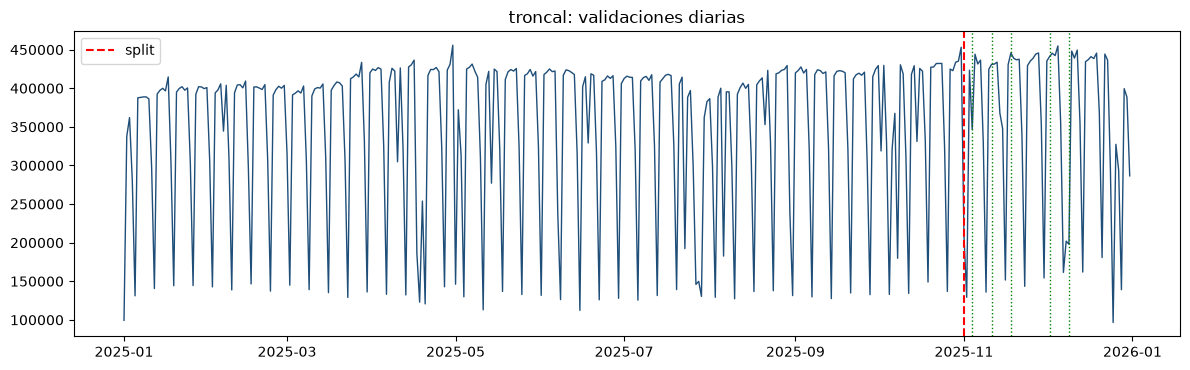

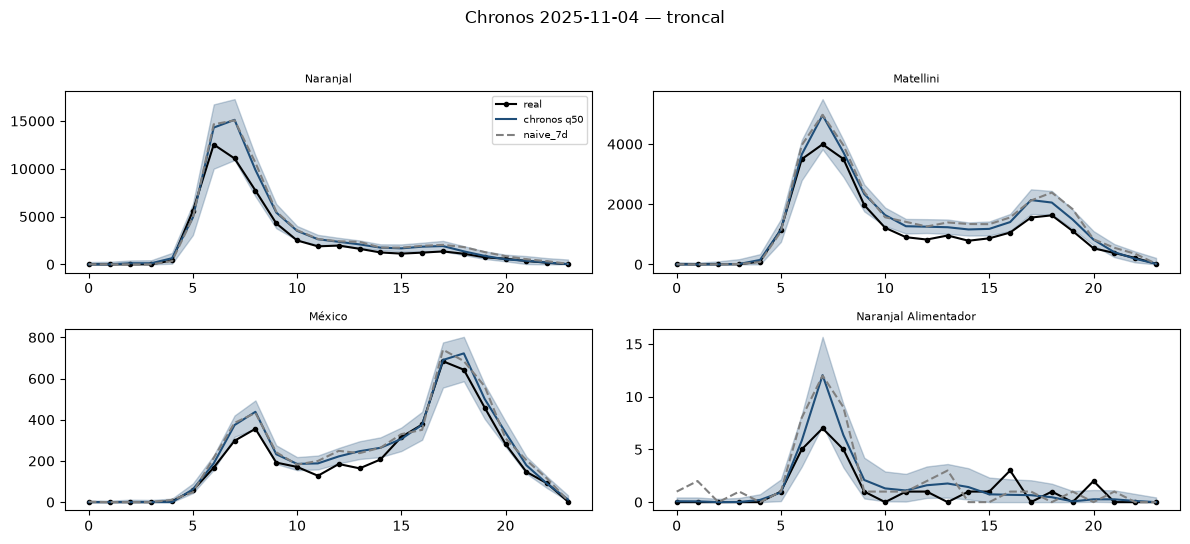

In [14]:

ser = grid[series_ok].sum(axis=1).resample("D").sum()
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(ser.index, ser.values, color=COLOR, lw=1)
ax.axvline(M.SPLIT, color="red", ls="--", label="split")
for d in M.DIAS_EVAL:
    ax.axvline(d, color="green", ls=":", lw=1)
ax.set_title(f"{SISTEMA}: validaciones diarias")
ax.legend()
plt.tight_layout()
fig.savefig(FIGS / "serie_diaria.png", bbox_inches="tight")
plt.show()

prom = grid.loc[:M.SPLIT, series_ok].mean().sort_values(ascending=False)
sel = list(prom.head(2).index) + [prom.index[len(prom)//2]] + [prom.index[-1]]
dia_ej = M.DIAS_EVAL[0]
yidx = pd.date_range(dia_ej, dia_ej + pd.Timedelta(hours=23), freq="h")
pos_ok, fc = M.pronostica_dia(pipeline, grid, dia_ej, series_ok)
mapa = {series_ok[p]: k for k, p in enumerate(pos_ok)}
q_mid = fc.shape[1] // 2

fig, axes = plt.subplots(2, 2, figsize=(12, 5.5))
for ax, e in zip(axes.ravel(), sel):
    ax.plot(range(24), grid.loc[yidx, e].values, "k.-", label="real")
    if e in mapa:
        k = mapa[e]
        ax.plot(range(24), fc[k, q_mid], color=COLOR, lw=1.5, label="chronos q50")
        ax.fill_between(range(24), fc[k, 0], fc[k, -1], color=COLOR, alpha=0.25)
    N = M.baseline_naive7d(grid, dia_ej, [e])
    if N is not None:
        ax.plot(range(24), N[0], "--", color="gray", label="naive_7d")
    ax.set_title(str(e)[:40], fontsize=8)
axes.ravel()[0].legend(fontsize=7)
plt.suptitle(f"Chronos {dia_ej.date()} — {SISTEMA}")
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FIGS / "chronos_ejemplo.png", bbox_inches="tight")
plt.show()


### Qué encontramos (plots)

La forma del día es propia de este modo. Un modelo mezclado L1+alimentador
aplastaría estas curvas.


## 3. Aforo proxy + ETA + recomendación 24h


In [17]:

df_ops, THR_MID, THR_HI, HW, CAPV = M.attach_ops(df_h, SISTEMA, P["FUENTES"])
print(f"Umbrales train: De_pie≥{THR_MID:.4f} Saturado≥{THR_HI:.4f}")
print(df_ops["aforo"].value_counts().to_string())
print("Headway buckets:", HW.get(SISTEMA))
print("Cap vehículo:", CAPV.get(SISTEMA))

pro, dia_fut = M.build_pronostico_24h(
    pipeline, grid, series_ok, SISTEMA, df_ops, THR_MID, THR_HI, HW, CAPV
)
pro.to_csv(OUT_DIR / "pronostico_24h.csv", index=False)
print(f"\nPronóstico 24h {dia_fut.date()}: {len(pro)} filas")
print(pro["recomendacion"].value_counts().to_string())
pro.head(4)


Umbrales train: De_pie≥0.1976 Saturado≥0.7845
aforo
Asientos    235879
De_pie      118387
Saturado     39934
Headway buckets: {'LAB': 9.558823529411764, 'SAB': 11.470588235294118, 'DOM': 17.205882352941178}
Cap vehículo: 164.0

Pronóstico 24h 2025-12-09: 1080 filas
recomendacion
abordar             642
cambiar_paradero    438


### Qué encontramos (producto)

Salida lista para UI de **este** modo. Capacidad/frecuencia son proxies; en
corredores/alimentadores la incertidumbre de oferta es mayor.


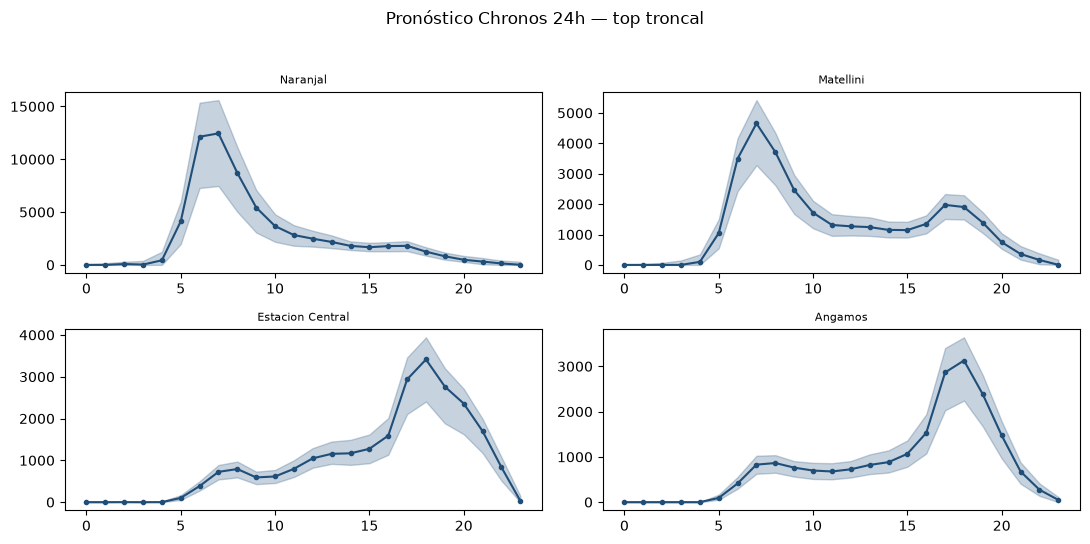

In [19]:

top = (pro.groupby("serie_id")["Validaciones_pron"].sum().sort_values(ascending=False).head(4).index)
fig, axes = plt.subplots(2, 2, figsize=(11, 5.5))
for ax, e in zip(axes.ravel(), top):
    g = pro[pro["serie_id"] == e].sort_values("Fecha_Hora")
    ax.plot(g["Fecha_Hora"].dt.hour, g["Validaciones_pron"], ".-", color=COLOR)
    ax.fill_between(g["Fecha_Hora"].dt.hour, g["Val_q10"], g["Val_q90"], color=COLOR, alpha=0.25)
    ax.set_title(str(e)[:42], fontsize=8)
plt.suptitle(f"Pronóstico Chronos 24h — top {SISTEMA}")
plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FIGS / "pronostico_24h_top.png", bbox_inches="tight")
plt.show()


## 4. Clasificador aforo (anti-leakage) + fidelidad regla U


 modelo  accuracy  balanced_acc  f1_macro  n_train  n_test
 LogReg    0.6140        0.4259    0.4032   200000   65880
     RF    0.7843        0.6658    0.6791   200000   65880
 HistGB    0.9295        0.9066    0.9122   200000   65880
XGBoost    0.9282        0.8997    0.9085   200000   65880

Mejor: HistGB f1= 0.9122
              precision    recall  f1-score   support

    Asientos       0.96      0.96      0.96     38998
      De_pie       0.88      0.89      0.89     19790
    Saturado       0.92      0.87      0.89      7092

    accuracy                           0.93     65880
   macro avg       0.92      0.91      0.91     65880
weighted avg       0.93      0.93      0.93     65880

Fidelidad árbol→regla U: 1.0000 (esperado ~1)


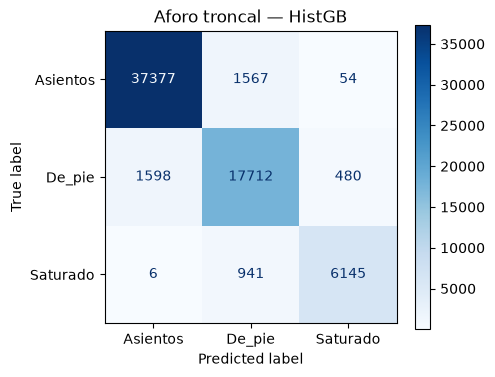

In [21]:

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

comp, best, yte = M.run_aforo_classifiers(df_ops)
comp.to_csv(OUT_DIR / "comparativa_aforo_modelos.csv", index=False)
print(comp.round(4).to_string(index=False))
name, f1, pred = best
print("\nMejor:", name, "f1=", round(f1, 4))
print(classification_report(yte, pred))
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(yte, pred, ax=ax, cmap="Blues")
ax.set_title(f"Aforo {SISTEMA} — {name}")
plt.tight_layout()
fig.savefig(FIGS / "aforo_cm.png", bbox_inches="tight")
plt.show()

# fidelidad regla
sample = df_ops.sample(min(60_000, len(df_ops)), random_state=42).sort_values(["serie_id", "Fecha_Hora"])
sample["next_aforo"] = sample.groupby("serie_id")["aforo"].shift(-1)
sample["recomendacion"] = [
    M.decision_u(e, a, n) for e, a, n in zip(sample["Headway_Min"], sample["aforo"], sample["next_aforo"])
]
sample = sample[sample["recomendacion"] != "desconocido"]
le_s = LabelEncoder().fit(df_ops["serie_id"])
sample["est_cod"] = le_s.transform(sample["serie_id"])
sample["af_cod"] = LabelEncoder().fit_transform(sample["aforo"])
sample["naf_cod"] = LabelEncoder().fit_transform(sample["next_aforo"].fillna("Asientos"))
Xr = sample[["Headway_Min", "af_cod", "naf_cod", "hora_n", "est_cod"]]
yr = sample["recomendacion"]
tree = DecisionTreeClassifier(max_depth=6, random_state=42).fit(Xr, yr)
fid = float((tree.predict(Xr) == yr).mean())
pd.DataFrame([{"modelo": "Tree_sobre_regla", "fidelidad_regla": fid}]).to_csv(
    OUT_DIR / "comparativa_recomendacion_fidelidad.csv", index=False
)
print(f"Fidelidad árbol→regla U: {fid:.4f} (esperado ~1)")


### Qué encontramos (aforo/regla)

El clasificador aprende régimen calendario×unidad de **este** sistema. La fidelidad
~1 del árbol confirma: la decisión de producto es la **regla U**, no ese ML.


## 5. Anomalías + manifiesto


Fecha_Hora  pct_outlier
2025-12-08     0.399074
2025-12-21     0.082407
2025-12-07     0.073148
2025-12-14     0.068519
2025-11-30     0.067593
Outputs: ['anomalias_diarias.csv', 'comparativa_aforo_modelos.csv', 'comparativa_recomendacion_fidelidad.csv', 'eval_walkforward_modelos.csv', 'manifiesto_modelamiento.json', 'metricas_modelos.csv', 'pronostico_24h.csv']


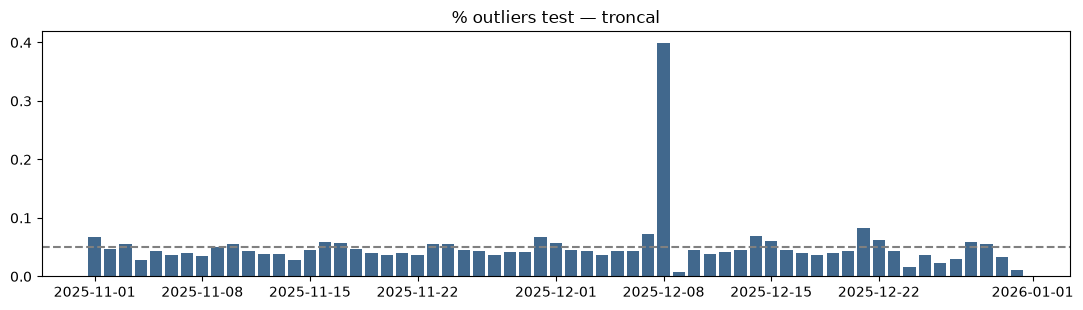

In [24]:

from sklearn.ensemble import IsolationForest

cols = ["Validaciones", "hora_n", "dow", "mes", "Headway_Min", "Ocupacion_proxy"]
Xctx = df_ops.loc[df_ops["Fecha_Hora"] <= M.SPLIT, cols].fillna(0)
mask = df_ops["Fecha_Hora"] > M.SPLIT
Xte = df_ops.loc[mask, cols].fillna(0)
if len(Xctx) > 150_000:
    Xctx = Xctx.sample(150_000, random_state=0)
ifo = IsolationForest(contamination=0.05, random_state=0, n_jobs=-1).fit(Xctx)
score = -ifo.score_samples(Xte)
te = df_ops.loc[mask, ["Fecha_Hora"]].copy()
te["outlier"] = score >= float(np.quantile(score, 0.95))
daily = te.groupby(te["Fecha_Hora"].dt.date)["outlier"].mean().rename("pct_outlier").reset_index()
daily.to_csv(OUT_DIR / "anomalias_diarias.csv", index=False)

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.bar(pd.to_datetime(daily.iloc[:, 0]), daily["pct_outlier"], color=COLOR, alpha=0.85, width=0.8)
ax.axhline(0.05, color="grey", ls="--")
ax.set_title(f"% outliers test — {SISTEMA}")
plt.tight_layout()
fig.savefig(FIGS / "anomalias.png", bbox_inches="tight")
plt.show()
print(daily.sort_values("pct_outlier", ascending=False).head(5).to_string(index=False))

M.save_manifest(
    SISTEMA, OUT_DIR,
    titulo=M.SISTEMAS[SISTEMA]["titulo"],
    grano=M.SISTEMAS[SISTEMA]["grano"],
    n_series=len(series_ok),
    split=str(M.SPLIT),
    dias_eval=[str(d.date()) for d in M.DIAS_EVAL],
    metricas=pivot.round(4).to_dict(),
    umbrales_aforo={"De_pie": THR_MID, "Saturado": THR_HI},
    nota="Modelo dedicado; no mezclar con otros sistemas en el mismo fit",
)
print("Outputs:", sorted(p.name for p in OUT_DIR.glob("*")))


## Conclusiones — Metropolitano Troncal

1. Este notebook entrena/evalúa **solo** `troncal`.
2. Chronos + walk-forward dan el pronóstico de validaciones de sus series.
3. Aforo/ETA son proxies; la recomendación es la regla U.
4. Para el producto: un endpoint / pipeline por modo (o un head por modo), no un
   único modelo Lima-global.
